In [1]:
import os
import io

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# librosa est une bibliothèque de traitement audio en Python, utilisée pour l'extraction de caractéristiques et la visualisation des signaux audio
import librosa

import matplotlib.pyplot as plt
import seaborn as sns


spark = SparkSession.builder.appName("SpeechEmotionRecognition").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/02/24 17:35:55 WARN Utils: Your hostname, DESKTOP-U89MV78, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/02/24 17:35:55 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/24 17:35:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [ ]:
# Charger les audios et leur chemins de fichiers dans un DataFrame Spark
dataset_path = os.path.abspath("Dataset/")
# On utilise binaryFile pour lire les fichiers audio en tant que données binaires
df_audio_raw = spark.read.format("binaryFile") \
    .option("recursiveFileLookup", "true") \
    .option("pathGlobFilter", "*.wav") \
    .load(dataset_path)

In [3]:
df_audio_raw.show(5)
df_audio_raw.count()

+--------------------+-------------------+------+--------------------+
|                path|   modificationTime|length|             content|
+--------------------+-------------------+------+--------------------+
|file:/home/ahrole...|2021-01-25 13:02:50|899200|[52 49 46 46 78 B...|
|file:/home/ahrole...|2021-01-25 13:02:18|863024|[52 49 46 46 28 2...|
|file:/home/ahrole...|2021-01-25 13:02:10|751848|[52 49 46 46 E0 7...|
|file:/home/ahrole...|2021-01-25 13:02:50|725050|[52 49 46 46 32 1...|
|file:/home/ahrole...|2021-01-25 13:02:12|687780|[52 49 46 46 9C 7...|
+--------------------+-------------------+------+--------------------+
only showing top 5 rows


12162

In [4]:
# Extraire les émotions à partir des chemins de fichiers
# On commence d'abord par ajouter une colonne dataset au dataframe pour différencier les datasets
df_audio_labeled = df_audio_raw.withColumn("path", F.col("path").cast("string")) \
    .withColumn("dataset",
                F.when(F.col("path").contains("Ravdess"), "RAVDESS")
                 .when(F.col("path").contains("Crema"), "CREMA")
                 .when(F.col("path").contains("Tess"), "TESS")
                 .when(F.col("path").contains("Savee"), "SAVEE")
    )

# Ensuite, on peut extraire les émotions à partir des chemins de fichiers en utilisant des expressions régulières
df_audio_labeled = df_audio_labeled.withColumn("label",
                                               F.when(F.col("dataset") == "RAVDESS",
                                                    F.regexp_extract("path", r"(\d{2})-(\d{2})-(\d{2})-", 3)) # On cherche XX-XX-XX- et on extrait le 3ème groupe (ex: 03-01-01- -> 01)

                                                .when(F.col("dataset") == "CREMA",
                                                    F.regexp_extract("path", r"_([A-Z]{3})_([A-Z]+)\.wav", 1)) # On cherche ABC_XX.wav et on extrait le 1er groupe (ex: _ANG_XX.wav -> ANG)

                                                .when(F.col("dataset") == "TESS",
                                                    F.regexp_extract("path", r"_([a-z]+)\.wav", 1)) # On cherche le mot juste avant .wav (ex: _angry.wav -> angry)
                                                
                                                .when(F.col("dataset") == "SAVEE",
                                                    F.regexp_extract("path", r"([a-z]+)\d{2}\.wav", 1)) # On prend la/les lettre(s) avant les chiffres du fichier (ex: a01.wav -> a)
)

In [5]:
# On procède à un mapping des labels pour les rendre plus compréhensibles et uniformes entre les datasets
mapping = {
    "happy": ["03", "HAP", "happy", "h"],
    "sad": ["04", "SAD", "sad", "sa"],
    "angry": ["05", "ANG", "angry", "a"],
    "fear": ["06", "FEA", "fear", "f"],
    "disgust": ["07", "DIS", "disgust", "d"],
    "surprise": ["08", "ps", "su"], # SAVEE n'a pas de surprise, on prend ps pour "pleasant surprise"
    "neutral": ["01", "NEU", "neutral", "n"],
    "calm": ["02"] # Existe seulement dans RAVDESS
}

df_final = df_audio_labeled.withColumn("label",
                                       F.when(F.col("label").isin(mapping["happy"]), "happy")
                                        .when(F.col("label").isin(mapping["sad"]), "sad")
                                        .when(F.col("label").isin(mapping["angry"]), "angry")
                                        .when(F.col("label").isin(mapping["fear"]), "fear")
                                        .when(F.col("label").isin(mapping["disgust"]), "disgust")
                                        .when(F.col("label").isin(mapping["surprise"]), "surprise")
                                        .when(F.col("label").isin(mapping["neutral"]), "neutral")
                                        .when(F.col("label").isin(mapping["calm"]), "calm")
                                        .otherwise("unknown")
)
df_final.show(10)

+--------------------+-------------------+------+--------------------+-------+--------+
|                path|   modificationTime|length|             content|dataset|   label|
+--------------------+-------------------+------+--------------------+-------+--------+
|file:/home/ahrole...|2021-01-25 13:02:50|899200|[52 49 46 46 78 B...|RAVDESS|    fear|
|file:/home/ahrole...|2021-01-25 13:02:18|863024|[52 49 46 46 28 2...|RAVDESS|    calm|
|file:/home/ahrole...|2021-01-25 13:02:10|751848|[52 49 46 46 E0 7...|RAVDESS|    calm|
|file:/home/ahrole...|2021-01-25 13:02:50|725050|[52 49 46 46 32 1...|RAVDESS|   happy|
|file:/home/ahrole...|2021-01-25 13:02:12|687780|[52 49 46 46 9C 7...|RAVDESS|surprise|
|file:/home/ahrole...|2021-01-25 13:03:06|629680|[52 49 46 46 A8 9...|  SAVEE|     sad|
|file:/home/ahrole...|2021-01-25 13:03:04|619634|[52 49 46 46 6A 7...|  SAVEE|   angry|
|file:/home/ahrole...|2021-01-25 13:03:08|618554|[52 49 46 46 32 7...|  SAVEE| disgust|
|file:/home/ahrole...|2021-01-25

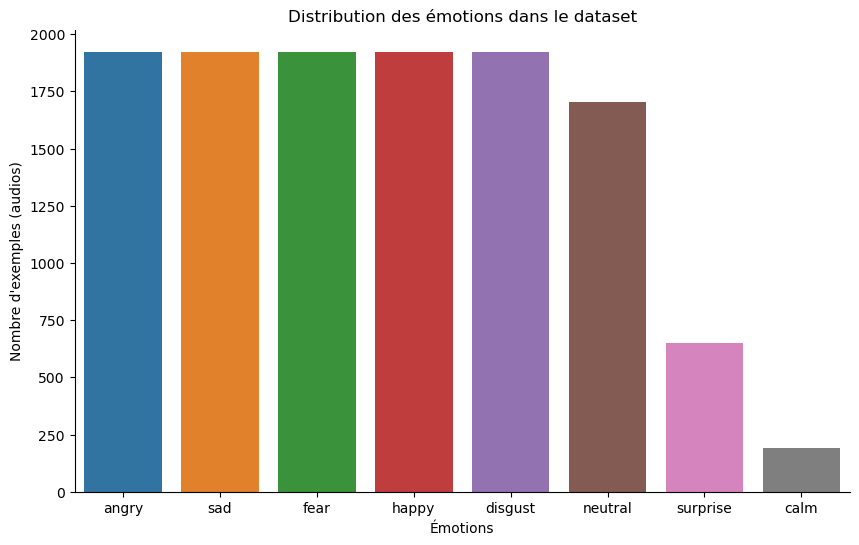

In [6]:
# df_final.groupBy("label").count().orderBy("count", ascending=False).show()

# Convertir le DataFrame Spark en Pandas pour la visualisation
pdf_counts = df_final.groupBy("label").count().toPandas()

# Visualiser la distribution des émotions
plt.figure(figsize=(10, 6))
sns.barplot(x="label", y="count", data=pdf_counts.sort_values("count", ascending=False), hue="label", palette="tab10")
sns.despine()
plt.title("Distribution des émotions dans le dataset")
plt.xlabel("Émotions")
plt.ylabel("Nombre d'exemples (audios)")
plt.show()

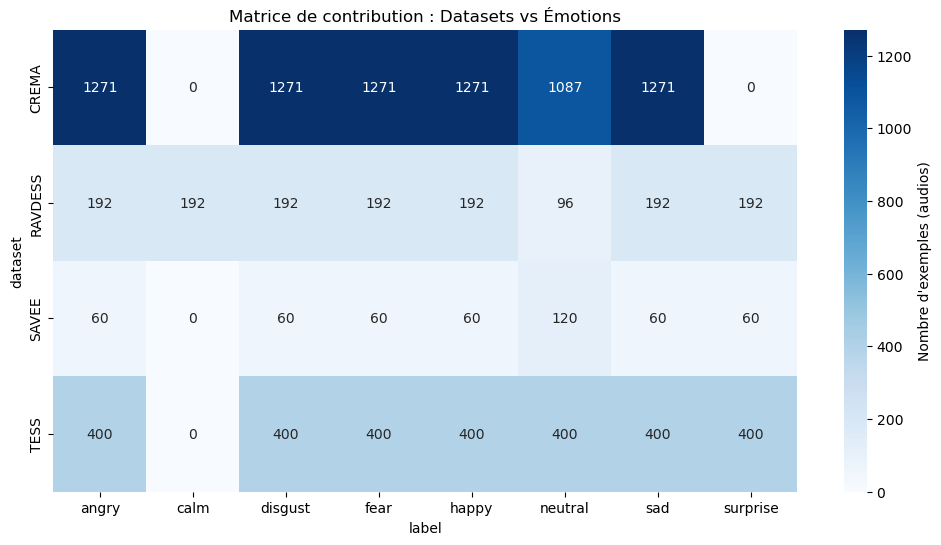

In [7]:
# Groupement par dataset et label
pdf_distribution = df_final.groupBy("dataset", "label").count().toPandas()

# Visualisation de la contribution de chaque dataset par émotion en diagramme à barres empilées
# df_final.groupBy("label").count().orderBy("count", ascending=False).show()
# pdf_distribution.head()
# plt.figure(figsize=(12, 7))
# sns.histplot(binwidth=0.5, x="label", hue="dataset", data=pdf_distribution, weights="count", multiple="stack", stat="count")
# sns.despine()
# plt.title("Contribution de chaque dataset par émotion")
# plt.show()

# Pivot pour avoir les datasets en lignes et labels en colonnes
heatmap_data = pdf_distribution.pivot(index="dataset", columns="label", values="count").fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Blues", cbar_kws={'label': 'Nombre d\'exemples (audios)'})

plt.title("Matrice de contribution : Datasets vs Émotions")
plt.show()

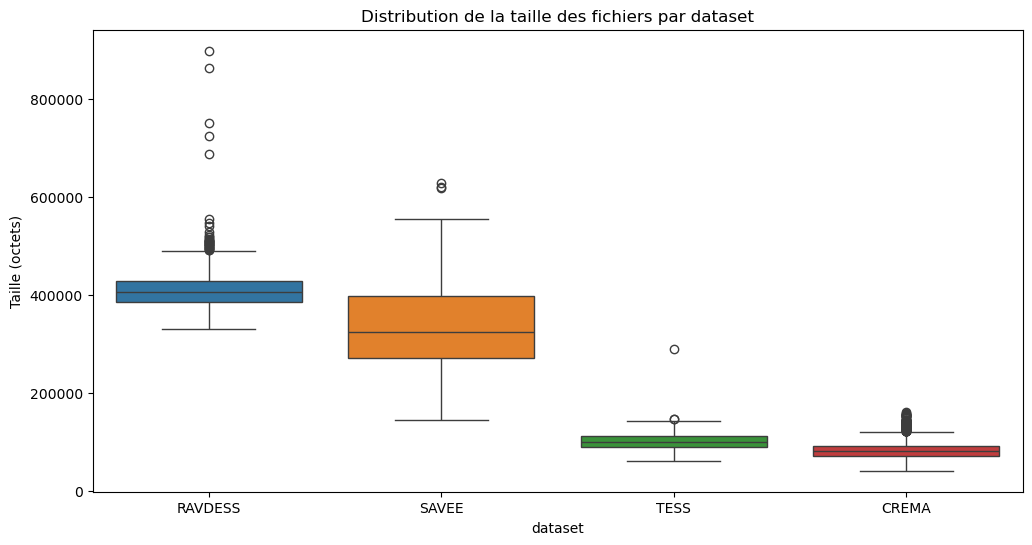

Au vu du résultat, on peut voir que les tailles des fichiers varient beaucoup entre les datasets, ce qui peut poser problème pour l'entraînement. 
Il faudra peut-être normaliser les durées des audios. On devrait envisager aussi de supprimer les fichiers qui sont trop courts.


In [8]:
## Analyse de la durée des audios

# Récupération des tailles de fichiers
pdf_lengths = df_final.select("length", "dataset", "label").toPandas()

plt.figure(figsize=(12, 6))
sns.boxplot(x="dataset", y="length", hue="dataset", data=pdf_lengths)
# plt.yscale('log') # On utilise une échelle log car les différences peuvent être grandes
plt.title("Distribution de la taille des fichiers par dataset")
plt.ylabel("Taille (octets)")
plt.show()

print("""Au vu du résultat, on peut voir que les tailles des fichiers varient beaucoup entre les datasets, \
ce qui peut poser problème pour l'entraînement. 
Il faudra peut-être normaliser les durées des audios. On devrait envisager aussi de supprimer les fichiers qui sont trop courts.""")

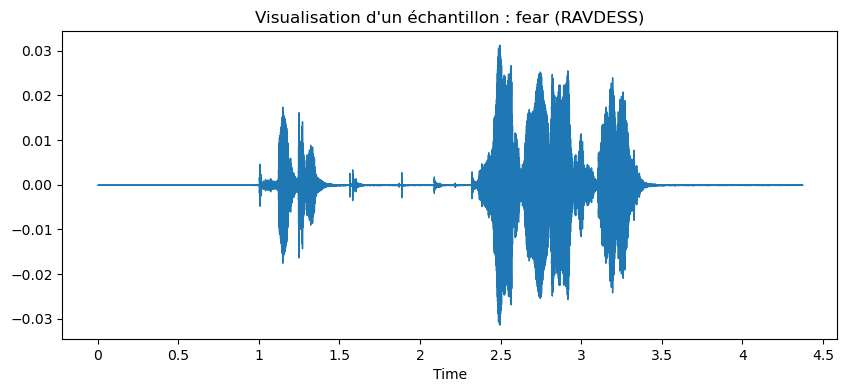

Au vu du résultat, on peut constater qu'il y a des "blancs" en début et fin d'audio.
Lors de l'extraction des caractéristiques(features), il faudra peut-être faire du trimming pour supprimer ces silences inutiles.


In [9]:
# On prend un échantillon au hasard
sample = df_final.limit(1).collect()[0]
audio_bytes = sample['content']

# Convertir les bytes en signal audio
with io.BytesIO(audio_bytes) as b:
    y, sr = librosa.load(b, sr=None)

plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Visualisation d'un échantillon : {sample['label']} ({sample['dataset']})")
plt.show()

print("""Au vu du résultat, on peut constater qu'il y a des "blancs" en début et fin d'audio.
Lors de l'extraction des caractéristiques(features), il faudra peut-être faire du trimming pour supprimer ces silences inutiles.""")

In [10]:
# Check if directory exists if not create
os.makedirs("Dataset/processed", exist_ok=True)

metadata_path = os.path.join("Dataset/processed", 'metadata.parquet')

df_final.coalesce(1).write.mode('overwrite').parquet(metadata_path)
print(f"metadata.parquet sauvegardé : {metadata_path}")

# Vérification : relire le fichier et compter
df_verify = spark.read.parquet(metadata_path)
n_verify = df_verify.count()
print(f"Vérification lecture : {n_verify:,} lignes")
df_verify.groupBy('label').count().orderBy('count', ascending=False).show()

print('\n' + "="*55)
print(f"  Total fichiers       : {n_verify:,}")
print("="*55)
spark.stop()

26/02/24 17:36:17 WARN TaskSetManager: Stage 13 contains a task of very large size (1811 KiB). The maximum recommended task size is 1000 KiB.


metadata.parquet sauvegardé : Dataset/processed/metadata.parquet
Vérification lecture : 12,162 lignes
+--------+-----+
|   label|count|
+--------+-----+
|   angry| 1923|
|     sad| 1923|
|    fear| 1923|
|   happy| 1923|
| disgust| 1923|
| neutral| 1703|
|surprise|  652|
|    calm|  192|
+--------+-----+


  Total fichiers       : 12,162
